<a href="https://colab.research.google.com/github/roug047/Unraveling-ASD-Susceptibility-Markers-for-Predictive-Diagnosis/blob/CO_project/diabetes1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
files.upload()

Saving diabetes1.csv to diabetes1.csv


{'diabetes1.csv': b'Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome\r\n6,148,72,35,0,33.6,0.627,50,1\r\n1,85,66,29,0,26.6,0.351,31,0\r\n8,183,64,0,0,23.3,0.672,32,1\r\n1,89,66,23,94,28.1,0.167,21,0\r\n0,137,40,35,168,43.1,2.288,33,1\r\n5,116,74,0,0,25.6,0.201,30,0\r\n3,78,50,32,88,31,0.248,26,1\r\n10,115,0,0,0,35.3,0.134,29,0\r\n2,197,70,45,543,30.5,0.158,53,1\r\n8,125,96,0,0,0,0.232,54,1\r\n4,110,92,0,0,37.6,0.191,30,0\r\n10,168,74,0,0,38,0.537,34,1\r\n10,139,80,0,0,27.1,1.441,57,0\r\n1,189,60,23,846,30.1,0.398,59,1\r\n5,166,72,19,175,25.8,0.587,51,1\r\n7,100,0,0,0,30,0.484,32,1\r\n0,118,84,47,230,45.8,0.551,31,1\r\n7,107,74,0,0,29.6,0.254,31,1\r\n1,103,30,38,83,43.3,0.183,33,0\r\n1,115,70,30,96,34.6,0.529,32,1\r\n3,126,88,41,235,39.3,0.704,27,0\r\n8,99,84,0,0,35.4,0.388,50,0\r\n7,196,90,0,0,39.8,0.451,41,1\r\n9,119,80,35,0,29,0.263,29,1\r\n11,143,94,33,146,36.6,0.254,51,1\r\n10,125,70,26,115,31.1,0.205,41,1\r\n7,147,76,0,0,39.4,0.257,4

In [3]:
import numpy as np
import pandas as pd
df = pd.read_csv("diabetes1.csv")


In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [6]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [8]:
df.loc[5:10, 'Glucose'] = np.nan
df.loc[15:20, 'BMI'] = np.nan

In [9]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,6
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,6
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [11]:
df.fillna(df.median(), inplace=True)

In [12]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [13]:
filtered_df = df[df['Glucose'] > 120]

In [14]:
filtered_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72,35,0,33.6,0.627,50,1
2,8,183.0,64,0,0,23.3,0.672,32,1
4,0,137.0,40,35,168,43.1,2.288,33,1
11,10,168.0,74,0,0,38.0,0.537,34,1
12,10,139.0,80,0,0,27.1,1.441,57,0


In [15]:
grouped_stats = df.groupby('Outcome').agg(['mean', 'std'])

In [16]:
grouped_stats


Pregnancies               Glucose            BloodPressure             \
               mean       std        mean        std          mean        std   
Outcome                                                                         
0          3.298000  3.017185  110.000000  26.144504     68.184000  18.063075   
1          4.865672  3.741239  141.074627  31.608591     70.824627  21.491812   

        SkinThickness                Insulin                    BMI            \
                 mean        std        mean         std       mean       std   
Outcome                                                                         
0           19.664000  14.889947   68.792000   98.865289  30.267000  7.657896   
1           22.164179  17.679711  100.335821  138.689125  35.097761  7.228833   

        DiabetesPedigreeFunction                  Age             
                            mean       std       mean        std  
Outcome                                                           
0                       0.429734  0.299085  31.190000  11.667655  
1                       0.550500  0.372354  37.067164  10.968254

In [17]:
df1 = df[['Pregnancies', 'Glucose', 'BloodPressure', 'Outcome']]
df2 = df[['BMI', 'Age', 'Outcome']]

In [19]:
merged_df = pd.merge(df1, df2, on='Outcome')

In [20]:
merged_df.head()

,Pregnancies,Glucose,BloodPressure,Outcome,BMI,Age
0,6,148.0,72,1,33.6,50
1,6,148.0,72,1,23.3,32
2,6,148.0,72,1,43.1,33
3,6,148.0,72,1,31.0,26
4,6,148.0,72,1,30.5,53


In [21]:
df['Glucose_BMI_Ratio'] = df['Glucose'] / df['BMI']

In [22]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_BMI_Ratio
0,6,148.0,72,35,0,33.6,0.627,50,1,4.404762
1,1,85.0,66,29,0,26.6,0.351,31,0,3.195489
2,8,183.0,64,0,0,23.3,0.672,32,1,7.854077
3,1,89.0,66,23,94,28.1,0.167,21,0,3.167260
4,0,137.0,40,35,168,43.1,2.288,33,1,3.178654


In [23]:
correlation_matrix = df.corr()

In [24]:
correlation_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_BMI_Ratio
Pregnancies,1.000000,0.131269,0.141282,-0.081672,-0.073535,0.023307,-0.033523,0.544341,0.221898,0.083891
Glucose,0.131269,1.000000,0.151221,0.053628,0.319884,0.225795,0.139923,0.257633,0.465860,0.710259
BloodPressure,0.141282,0.151221,1.000000,0.207371,0.088933,0.282703,0.041265,0.239528,0.065068,-0.007169
SkinThickness,-0.081672,0.053628,0.207371,1.000000,0.436783,0.385580,0.183928,-0.113970,0.074752,-0.233755
Insulin,-0.073535,0.319884,0.088933,0.436783,1.000000,0.193435,0.185071,-0.042163,0.130548,0.135725
BMI,0.023307,0.225795,0.282703,0.385580,0.193435,1.000000,0.141140,0.037444,0.293438,-0.493564
DiabetesPedigreeFunction,-0.033523,0.139923,0.041265,0.183928,0.185071,0.141140,1.000000,0.033561,0.173844,-0.000465
Age,0.544341,0.257633,0.239528,-0.113970,-0.042163,0.037444,0.033561,1.000000,0.238356,0.211271
Outcome,0.221898,0.465860,0.065068,0.074752,0.130548,0.293438,0.173844,0.238356,1.000000,0.169739
Glucose_BMI_Ratio,0.083891,0.710259,-0.007169,-0.233755,0.135725,-0.493564,-0.000465,0.211271,0.169739,1.000000


In [25]:
import matplotlib.pyplot as plt

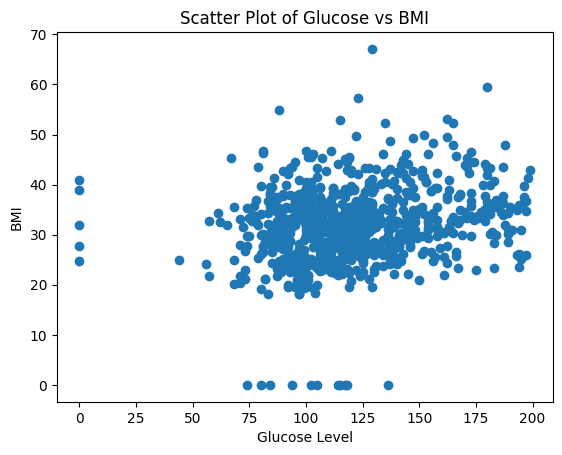

In [26]:
plt.scatter(df['Glucose'], df['BMI'])
plt.xlabel('Glucose Level')
plt.ylabel('BMI')
plt.title('Scatter Plot of Glucose vs BMI')
plt.show()